![](../../../images/header.png)

# Mapping the Universe

<h6>Author : Hernan Rincon</h6>
<h6>Last Updated : October 11, 2025</h6>

The DESI Survey is making a giant, three-dimensional map of the universe. This map will allow scientists to study some of the biggest mysteries in physics, chief among them being the nature of dark energy. Most maps that you see in your day-to-day life are two-dimensional, so it may be hard to picture what a three dimensional map looks like in your head. This notebook will detail how DESI is creating its map of the universe, what this map looks like, and how you can create your own version of such a map with DESI data.

By the end of this notebook, you should be able to:
- Read maps of the night sky with right ascension and declination coordinates
- Understand the concept of a survey footprint and how DESI observes the night sky with overlapping survey tiles
- Create a three-dimensional map of DESI galaxies along with a corresponding two-dimensional cross section

## Preferred Backgrounds
While not necessary, having knowledge about the following topics will be helpful in completing this notebook on time:

- How Jupyter cells work
- How to depict data visually by using graphs

**Run the cell below to load the basic Python packages we need to run this notebook.**

In [1]:
import numpy as np
import healpy as hp
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from desihigh.plot_utilities import angle_degrees_formatter

ModuleNotFoundError: No module named 'desihigh'

## 1 - Map Projections

Before we discuss maps of the universe, let's first introduce maps of the Earth. Since our planet Earth is a sphere, we will often make maps that are **projections** of this sphere onto a flat surface, like the one seen below.

<img src="../../../images/Earth-Mollweide-projection.jpg" alt="" width="600"/>

<h6> Source : <a href="https://earthobservatory.nasa.gov/">NASA Earth Observatory</a></h6>

Maps that are projections will often distort the shapes of Earth's continents in order to represent a three-dimensional planet on a two-dimensional surface. That is the case for the map pictured above.

Maps of the night sky can also be projected onto a two-dimensional map. The below map is one such example. This map shows the band of the Milky Way galaxy, which you can see by eye in dark night skies far away from city lights.

<img src="../../../images/Milky_Way_infrared.jpg" alt="" width="600"/>

<h6> Source : <a href="https://www.ipac.caltech.edu/2mass/">Two Micron All Sky Survey</a></h6>

As is the case for Earth's continents, objects in the night sky may appear distorted by the projection of the map. To better understand how this distortion behaves, let's make our own map of the night sky. We will use data from the <a href="https://map.gsfc.nasa.gov/">WMAP collaboration</a> that tells us how hot or cold the electromagnetic radiation in different parts of the night sky is.

First, let's load in the WMAP temperature data.

In [ ]:
# load in temperature map data
sky_map = hp.read_map('../../../data/wmap_band_iqumap_r9_7yr_W_v4.fits')

Now let's create a map of the temperature of the night sky. The appearance of the map will depend on the rotation at which we view it. Run the below cell to create the map.

In [ ]:
# Try changing the value of map_rotation_angle to various 
# values between 0 and 360 degrees and observe how the 
# apparence of the map changes

map_rotation_angle = 45 # in units of degrees

# create the map by using the mollview function
hp.mollview(
    sky_map,
    rot = (0, 0, map_rotation_angle),
    title="Temperature Map of the Night Sky",
    unit="excess temperature (millikelvin)",
    min=-1,
    max=2,
    cmap = mpl.colormaps['bone']
)


### 1.1 - Longitude and Latitude

<img src="../../../images/Earth-Mollweide-projection.jpg" alt="" width="600"/>

<h6> Source : <a href="https://earthobservatory.nasa.gov/">NASA Earth Observatory</a></h6>


To tell where we are located on our planet Earth, we can use **longitude (long.)** and **latitude (lat.)**. Longitude and latitude are angles and have units of degrees (°). To become more familiar with these units, let’s take a look at the below map. Our friend BaoBan the coyote (the DESI outreach ambassador) is hanging out in the center of the map.

<img src="../../../images/latlong/Earth-Mollweide-projection_0.jpg" alt="" width="600"/>

The blue line on this map is called the equator, and it passes through South America, Africa, and Asia (and BaoBan). When we are on the equator, we have a latitude of 0 degrees. When we are north of (above) the equator, we have a positive latitude value, with the largest possible latitude value being 90 degrees at the north pole. When we are south of (below) the equator, we have a negative latitude value, with the lowest possible latitude value being -90 degrees at the south pole.

The green line on the map is called the Prime Meridian, and it passes through Europe, Africa, and Antarctica (and BaoBan). When we are on the Prime Meridian, we have a longitude of 0 degrees. When we are east (right) of the Prime Meridian, we have a positive longitude with the largest possible latitude value being 180 degrees on the eastern edge of the map. When we are west (left) of the equator, we have a negative latitude value, with the lowest possible longitude value being -180 degrees at the western edge of the map.


The equator and the Prime Meridian cross each other in the center of the map. BaoBan is at this location, which is labeled 0 degrees longitude and 0 degrees latitude. Let’s now go with BaoBan on an adventure around the world. If BaoBan moves east (right) on the map, then his longitude value will increase from 0.

<img src="../../../images/latlong/Earth-Mollweide-projection_1.jpg" alt="" width="600"/>

Now BaoBan has a longitude of 34 degrees and a latitude of 0 degrees, and he is near Lake Victoria. This lake is one of the largest in the world and is bordered by several countries in Africa. If BaoBan next moves north (up) on the map, his latitude will increase from 0.

<img src="../../../images/latlong/Earth-Mollweide-projection_2.jpg" alt="" width="600"/>

BaoBan now has a longitude of 34 degrees and a latitude of 40 degrees, and he is in the country of Turkey. If he next moves to the east, his longitude value will increase, and he will pass through Asia and cross the Pacific Ocean. He will then wrap around the edge of the map and arrive in North America.

<img src="../../../images/latlong/Earth-Mollweide-projection_3.jpg" alt="" width="600"/>

Now BaoBan has a longitude of 286 degrees and a latitude of 40 degrees. He is in the United States. Now he is west (left) of the Prime Meridian, so it would be conventional to write his longitude as a negative value. However, we are going to use our own custom convention and keep his longitude as a positive number. Next, BaoBan is going to head south, so his latitude will decrease.

<img src="../../../images/latlong/Earth-Mollweide-projection_4.jpg" alt="" width="600"/>

BaoBan is now south of the equator, so he has a negative latitude of -14 degrees. He is in the country of Peru. For the last stretch of his journey, he will move east, so his longitude will increase.

<img src="../../../images/latlong/Earth-Mollweide-projection_5.jpg" alt="" width="600"/>

Now BaoBan is back at the Prime Meridian, and his longitude has increased to 360 degrees. Since there are only 360 degrees in a circle, an angle of 360 degrees is equivalent to an angle of 0 degrees. So we can also say that Baoban has a longitude of 0 degrees.

TODO: add some images of locaitons ot break up teh trvel, add a plotting excersize where ou can specify lon lat

In [2]:
earth_map = np.fromfile('../../../data/earth_map_healpix.BIN', dtype=np.float32)


can you find a lat lon value in north America? Africa? Australia? Antartica?

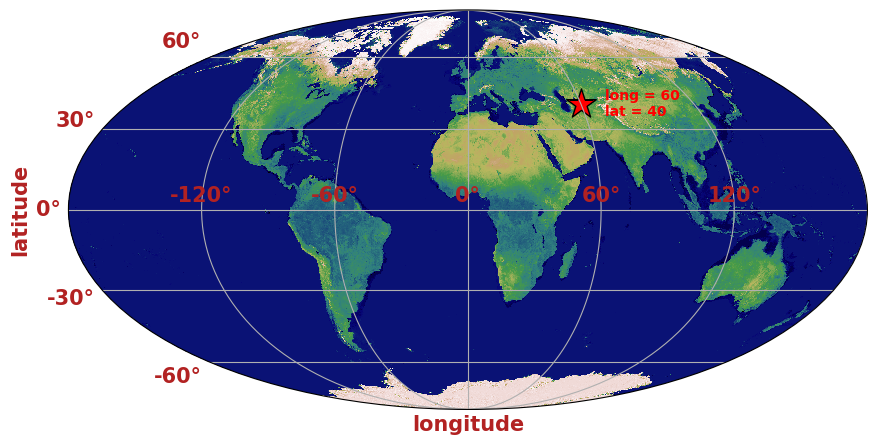

In [5]:
longitude = 60
latitude = 40

hp.newvisufunc.projview(earth_map, cmap="gist_earth", flip="geo", cbar=None,
                        graticule=True,
                        graticule_labels=True,
                        fontsize={'xlabel':15,'ylabel':15,'xtick_label':15,'ytick_label':15},
                        custom_xtick_labels=["-120°", "-60°", "0°", "60°", "120°"]
                       )

plt.scatter(np.deg2rad([longitude]), np.deg2rad([latitude]), color='red', marker='*', s=500, edgecolors='black');
plt.text(np.deg2rad([longitude+10]), np.deg2rad([latitude-5]), f'long = {longitude}\nlat = {latitude}',color='red', weight='bold');

axis = plt.gca()

axis.tick_params(colors='firebrick')
axis.set_xlabel('longitude', color='firebrick', weight='bold')
axis.set_ylabel('latitude', color='firebrick', weight='bold')
for label in axis.get_xticklabels() + axis.get_yticklabels():
    label.set_fontweight('bold')

In [ ]:
rotation = 125
hp.newvisufunc.projview(earth_map, cmap="gist_earth", flip="geo", cbar=None, rot=rotation,
                        graticule=True,
                        graticule_labels=True,
                        fontsize={'xlabel':15,'ylabel':15,'xtick_label':15,'ytick_label':15},
                        custom_xtick_labels=["-120°", "-60°", "0°", "60°", "120°"]
                       )


TODO: figure out how to get sky version working

Let's use the information from this nightly plan to plot the path that DESI takes across the night sky. The right ascension and declination data from the plan are copied below into python lists. **Now, you should use the `matplotlib` python package to plot the declination values on the y-axis and R.A. values on the x-axis. When you’re done, you’ll be able to see the path through the sky that DESI takes on a night of observations. Make sure to include axis labels and a title for the plot.**

In [ ]:
# load up right ascension and declination coordinates of tiles for the 2021-09-22 DESI observing plan
ra = np.fromfile('../../../data/20210922_tiles_ra.BIN')
declination = np.fromfile('../../../data/20210922_tiles_dec.BIN')


# =================================================================

# YOUR CODE GOES HERE
# Create a plot showing the desi tiles in the plan for 2021-09-22
# Hint: use plt.scatter to show the individual tiles 
# and plt.plot to show the path connecting them

# =================================================================


# add some text to the plot to show where the first and last tiles of the night are located
plt.scatter([266.0, 109.3], [24.8, 40.0], color='red')
plt.text(266.0, 24.8, 'start of the night\n(7:15 pm)')
plt.text(109.3, 40.0, 'end of the night \n(5:19 am)')

# invert the plot's x-axis so that larger right ascension values appear on the left
plt.gca().invert_xaxis()

# Treat the x-axis of the plot as an angle, so that values of 360 degrees wrap
# back around to zero degrees
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(angle_degrees_formatter))

Compare your plot with the DESI footprint map we saw before. **Did DESI plan to observe in both the North Galactic Cap footprint and the South Galactic Cap footprint on 2021-09-22?**

<img src="../../../images/dr1-bright-progress.png" alt="" width="600"/>

<h6> Source : <a href="https://arxiv.org/abs/2503.14745">First Public Data Release of the DESI Survey</a></h6>

The green circles in the above map are individual DESI tiles. As the DESI survey carries on, multiple overlapping tiles pile up to cover the entire DESI footprint. You can see this overlapping coverage staring to take effect in the dark green regions.

Now that we have a plan for the night, it’s time for our collaboration members to start observing. Much of the observing process can be controlled and monitored from the observing console station, which is in the same building as the telescope. Observing on 2021-09-22 started at 7:15 pm and ended at 5:19 am. DESI observers have to stay up all night to work!

<img src="../../../images/observing_console.jpg" alt="" width="600"/>

<h6> Source : Claire Lamman</a></h6>

The above image shows DESI observers working at the observing console station.

A night of observing won’t always go according to schedule. Clouds, weather, atmospheric conditions, and problems with observing equipment can all cause less tiles to be observed on a particular night than are planned.

# 2 - Mapping Cross Sections of DESI Data

Now that you've had a chance to examine two-dimensional maps of the night sky, we're going to move to three-dimensional maps. It's not straightforward to make maps of three-dimensional structures when our map pages (or our computer screens) are flat, two-dimensional surfaces. However, one trick that we can use is to plot a cross-section of a structure, meaning that we plot a flat, two-dimensional slice through the middle of the structure. For example, cross-sections of the Earth show the underground layers of our planet that are normally hidden from our eyes.

<img src="../../../images/MTU-Earth-cross-section.jpg" alt="" width="600"/>

<h6> Source : <a href="https://www.usgs.gov/">U.S. Geological Survey</a></h6>


We can create a similar cross section of DESI data to visually depict our universe. The maps we’ve seen so far don’t tell us how far away distant galaxies are from us, only where they appear in our night sky. But with DESI’s distance measurements of galaxies (see the Redshift and Distance notebok for more information), we can create a cross-sectional map of the universe with the distances between galaxies now depicted. When we do that, we obtain the below image.

<img src="../../../images/MTU-cross-section.jpg" alt="" width="600"/>

<h6> Source : David Schlegel and LBNL</h6>

In the above map, each dot of light is an entire galaxy. There are tens of millions of them depicted here, with our own galaxy placed at the center of the map. You'll notice that there are dark wedges on the map where there appear to be no galaxies. These dark wedges are the result of the Milky Way galaxy blocking our view of certain parts of the sky. There are countless galaxies in these regions, but they are hidden from DESI.

Now lets make our own map of DESI's galaxies. We will import the `get_x_y_z_region` function and use it to load up the cartesian X, Y, and Z positions of galaxies on a cubic grid. These galaxies come from the first public release of DESI data.

In [ ]:
from desihigh.galaxies import get_x_y_z_region

# load galaxy positions
x_positions, y_positions, z_positions = get_x_y_z_region('../../../data/DR1_BGS_sample_galaxies.BIN')

How many galaxies have we loaded in? Our `x_positions` variable is a numpy array, and we can use the `shape` property to report how many galaxies there are.

In [ ]:
x_positions.shape

That's quite a lot of galaxies! To make it easier to depict the galaxies in a three-dimensional plot, let's cut them down to a smaller region of space. To do so, we are going to create a **boolean mask** variable that selects only those galaxies that meet special conditions. The conditions we want to impose are

 - X Positions > -640 Mpc/h
 - X Positions < -560 Mpc/h
 - Y Positions > -200 Mpc/h
 - Y Positions < -120 Mpc/h
 - Z Positions > -40 Mpc/h
 - Z Positions < 40 Mpc/h

The galaxies that meet these conditions will fill a cube with a side length of 80 $\text{Mpc}/h$. Our units of distance are $\text{Mpc}/h$, with one $\text{Mpc}/h$ equaling about five million lightyears. We'll create our boolean mask with the below code.

In [ ]:
# create a boolean mask that will select only galaxies that meet certain conditions
# We can use the & symbol to combine multiple conditions
select_x = (x_positions > -640) & (x_positions < -560)

select_y = (y_positions > -200) & (y_positions < -120) 

select_z =  (z_positions > -40) & (z_positions < 40)

select_galaxies = select_x & select_y & select_z

Now let's use our boolean mask to cut down the number of galaxies that we will plot.

In [ ]:
print(f'We start with {x_positions.shape[0]} galaxies')

# apply a boolean mask to our coordinates to cut down the number of galaxies that we will plot
x_positions = x_positions[select_galaxies]
y_positions = y_positions[select_galaxies]
z_positions = z_positions[select_galaxies]

print(f'After applying our mask, we have {x_positions.shape[0]} galaxies')

Now run the below cell to create a three-dimensional map of DESI galaxies.

In [ ]:
plot_rotation = 15 # The rotation angle at which we view the plot (in units of degrees)

# create a three dimensional map of DESI galaxies by using matplotlib
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(x_positions, y_positions, z_positions, s = 0.1)

ax.set_xlabel('X Position [Mpc/h]', labelpad=10)
ax.set_ylabel('Y Position [Mpc/h]', labelpad=10)
ax.set_zlabel('Z Position [Mpc/h]', labelpad=10)

plt.title('3D Map of DESI Galaxies in Cubic Region')

ax.set_box_aspect(None, zoom=0.78)
ax.view_init(azim=plot_rotation)

plt.show()

Because we're trying to represent a three dimensional map on a two-dimensional screen, the result can be non-intuitive to look at. It may help to **vary the `plot_rotation` parameter in the above code**, which will allow you to view the plot from different angles.

To make our plot easier to understand, let's turn it into a two-dimensional cross section. **Create a boolean mask `select_cross_section` that selects a 10 Mpc/h-wide slice of galaxies in the X-Y plane, and use the below code to plot the slice that you created.**

In [ ]:
select_cross_section = # YOUR CODE GOES HERE

# plot a two-dimensional cross section of DESI galaxies
plt.scatter(x_positions[select_cross_section], y_positions[select_cross_section], s=0.5)
plt.axis('equal')
plt.title('10 Mpc/h-wide Cross Section of DESI Galaxies')
plt.xlabel('X Position [Mpc/h]')
plt.ylabel('Y Position [Mpc/h]')
plt.show()

You might notice in your cross-sectional map that some regions have many galaxies, and some regions have few galaxies. The way in which galaxies cluster together tells us about the evolutionary history of our universe and the underlying mathematical model of cosmology that describes it. 

In the earliest era of our universe that we can observe, the matter within it was evenly distributed. Some regions were slightly denser than others, but these variations in density were small, on the order of one part-per-hundred-thousand. Over the billions of years that followed, gravity caused these slightly overdense regions to collapse and form structures. Under the influence of gravity, the once uniform universe evolved to develop galaxies, clusters of galaxies, and highly overdense regions on its largest scales. These overdensities are what form the dense regions visible in your cross-sectional map.

We can use the distribution of galaxies in a map of the universe to test our models of dark energy and gravity and to better understand cosmology as a whole. We will turn in subsequent notebooks to examining the scientific analyses that are performed with DESI data. 

While our cross-sectional map depicts a specific region of DESI galaxies, we can also construct maps that span the entire DESI survey volume. An example of such a zoomed-out, cross-sectional map is shown below.

<img src="../../../images/MTU-DESI-map.png" alt="" width="600"/>

<h6> Source : <a href="https://www.desi.lbl.gov/2024/04/04/first-cosmology-results-from-desi-most-precise-measurement-of-the-expanding-universe/">Claire Lamman and the DESI Collaboration</a></h6>

Once again, we can see that galaxies cluster together to form web-like structures. What if we want to depict this map in three dimensions rather than using a cross section? As we saw before, three-dimensional maps can be challenging to depict on a two-dimensional screen. It helps however if we make our map intereactive, allowing us to move and rotate our field of view in real time. The DESI member Otavio Alves has created an interactive map that we can use to view DESI galaxies. **Try visiting https://fly.otavioalves.com/ and use your computer mouse to explore the universe as revealed by DESI.**


## Conclusion

In this notebook, we have introduced DESI's map of the universe along with the map projections and coordinate systems that we can use to depict DESI data. We have additionally described how a night of DESI observing works, using overlapping survey tiles to make progress toward the survey's completion. 

The way that galaxies cluster together in DESI's map allows us to test theoretical models of cosmology. In the next notebook, we will introduce various scientific analyses that we can perform with DESI.

![](../../../images/footer.png)

<details>
  <summary><h6>Code solutions, do not open if not allowed</h6></summary>
  
**Exercise 1 : Projecting the Milky Way**
```python
# Try changing the value of map_rotation_angle to various 
# values between 0 and 360 degrees and observe how the 
# apparence of the map changes

map_rotation_angle = 0 # in units of degrees

hp.mollview(
    sky_map,
    rot = (0, 0, map_rotation_angle),
    title="Temperature Map of the Night Sky",
    unit="excess temperature (millikelvin)",
    min=-1,
    max=2,
    cmap = mpl.colormaps['bone']
)
```
An angle of 0 degrees, 90 degrees, 180 degrees, or 270 degrees causes the Milky Way to appear flat.

**Exercise 2 : DESI's Path Through the Night Sky**
```python
# load up right ascension and declination coordinates of tiles for the 2021-09-22 DESI observing plan
ra = np.fromfile('../../../data/20210922_tiles_ra.BIN')
declination = np.fromfile('../../../data/20210922_tiles_dec.BIN')


# show the connected path that DESI takes through the night sky

plt.plot(ra, declination)
# show the locations of the indicidual tiles on the path
plt.scatter(ra, declination)

plt.xlabel('right ascension [degrees]')
plt.ylabel('declination [degrees]')
plt.title('Planned Path of DESI Survey Through The Sky on 2021-09-22')

# add some text to the plot to show where the first and last tiles of the night are located
plt.scatter([266.0, 109.3], [24.8, 40.0], color='red')
plt.text(266.0, 24.8, 'start of the night\n(7:15 pm)')
plt.text(109.3, 40.0, 'end of the night \n(5:19 am)')

# invert the plot's x-axis so that larger right ascension values appear on the left
plt.gca().invert_xaxis()

# Treat the x-axis of the plot as an angle, so that values of 360 degrees wrap
# back around to zero degrees
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(angle_degrees_formatter))

```
The DESI observing plan for 2021-09-22 included tiles in both the North Galactic Cap footprint and the South Galactic Cap footprint. The plan started and ended the night in the South Galactic Cap, while tiles in the middle of the night were in the Northern Galactic Cap.

**Exercise 3 : Creating a Cross Section of DESI Galaxies**
```python
select_cross_section = (z_positions > -5) * (z_positions < 5)

plt.scatter(x_positions[select_cross_section], y_positions[select_cross_section], s=0.5)
plt.axis('equal')
plt.title('10 Mpc/h-wide Cross Section of DESI Galaxies')
plt.xlabel('X Position [Mpc/h]')
plt.ylabel('Y Position [Mpc/h]')
plt.show()
```

  </details>